
# 08 — All-in-one report figure pipeline

This notebook is a **single, self-contained pipeline** for generating the polished report figures used in the BT4014 contextual-bandit project.

## What this notebook does
- uses a single setup cell and one consistent plotting style
- recreates the main polished figures for the report and slides
- exports all figures into `outputs/figures/`
- writes a small `policy_summary_table.csv` for convenient reporting

## Why this notebook exists
You asked for **one normal big Jupyter notebook** that does the work in one place, instead of many small fragmented notebooks.

## Notes
- The figures here are designed to be **report-friendly** and visually cleaner.
- The notebook is intentionally self-contained, so it does **not** depend on the large parquet files.
- If you want, this can live as your main public-facing notebook for the repo.



## Core modeling idea

We treat each interaction round as contextual decision-making.

For a context vector $x_t$ and arm $a$, a linear contextual model predicts expected reward via:

$$
\hat r_t(a) = x_t^\top \hat\theta_a
$$

For **LinUCB**, the optimistic action score is:

$$
\text{score}_t(a) = x_t^\top \hat\theta_a + \alpha \sqrt{x_t^\top A_a^{-1} x_t}
$$

For **Contextual Thompson Sampling**, we sample a parameter vector from an approximate posterior and choose:

$$
a_t = \arg\max_a x_t^\top \tilde\theta_a
$$

The cumulative regret after $T$ rounds is:

$$
R_T = \sum_{t=1}^T \left( r_t(a_t^*) - r_t(a_t) \right)
$$


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)

cwd = Path.cwd().resolve()
root = cwd.parent if cwd.name == 'notebooks' else cwd
out_dir = root / 'outputs' / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

def setup_style():
    plt.rcParams.update({
        'figure.facecolor': '#f4f4f4',
        'axes.facecolor': '#f4f4f4',
        'savefig.facecolor': '#f4f4f4',
        'axes.edgecolor': '#4a4a4a',
        'axes.labelcolor': '#222222',
        'xtick.color': '#222222',
        'ytick.color': '#222222',
        'grid.color': '#9a9a9a',
        'grid.alpha': 0.28,
        'axes.grid': True,
        'font.size': 11,
        'axes.titlesize': 16,
        'axes.titleweight': 'bold',
        'axes.labelsize': 12,
        'legend.framealpha': 0.93,
        'legend.facecolor': '#f8f8f8',
        'legend.edgecolor': '#d0d0d0',
    })

setup_style()

def savefig(name):
    path = out_dir / name
    plt.savefig(path, dpi=220, bbox_inches='tight')
    print('saved:', path)

print('Current working directory:', cwd)
print('Output folder:', out_dir)


Current working directory: C:\Users\hovha\Downloads\job-ui-contextual-bandits\notebooks
Output folder: C:\Users\hovha\Downloads\job-ui-contextual-bandits\outputs\figures


## 1) Simulator world statistics and sanity-check visuals

saved: C:\Users\hovha\Downloads\job-ui-contextual-bandits\outputs\figures\01_simulator_world_stats.png


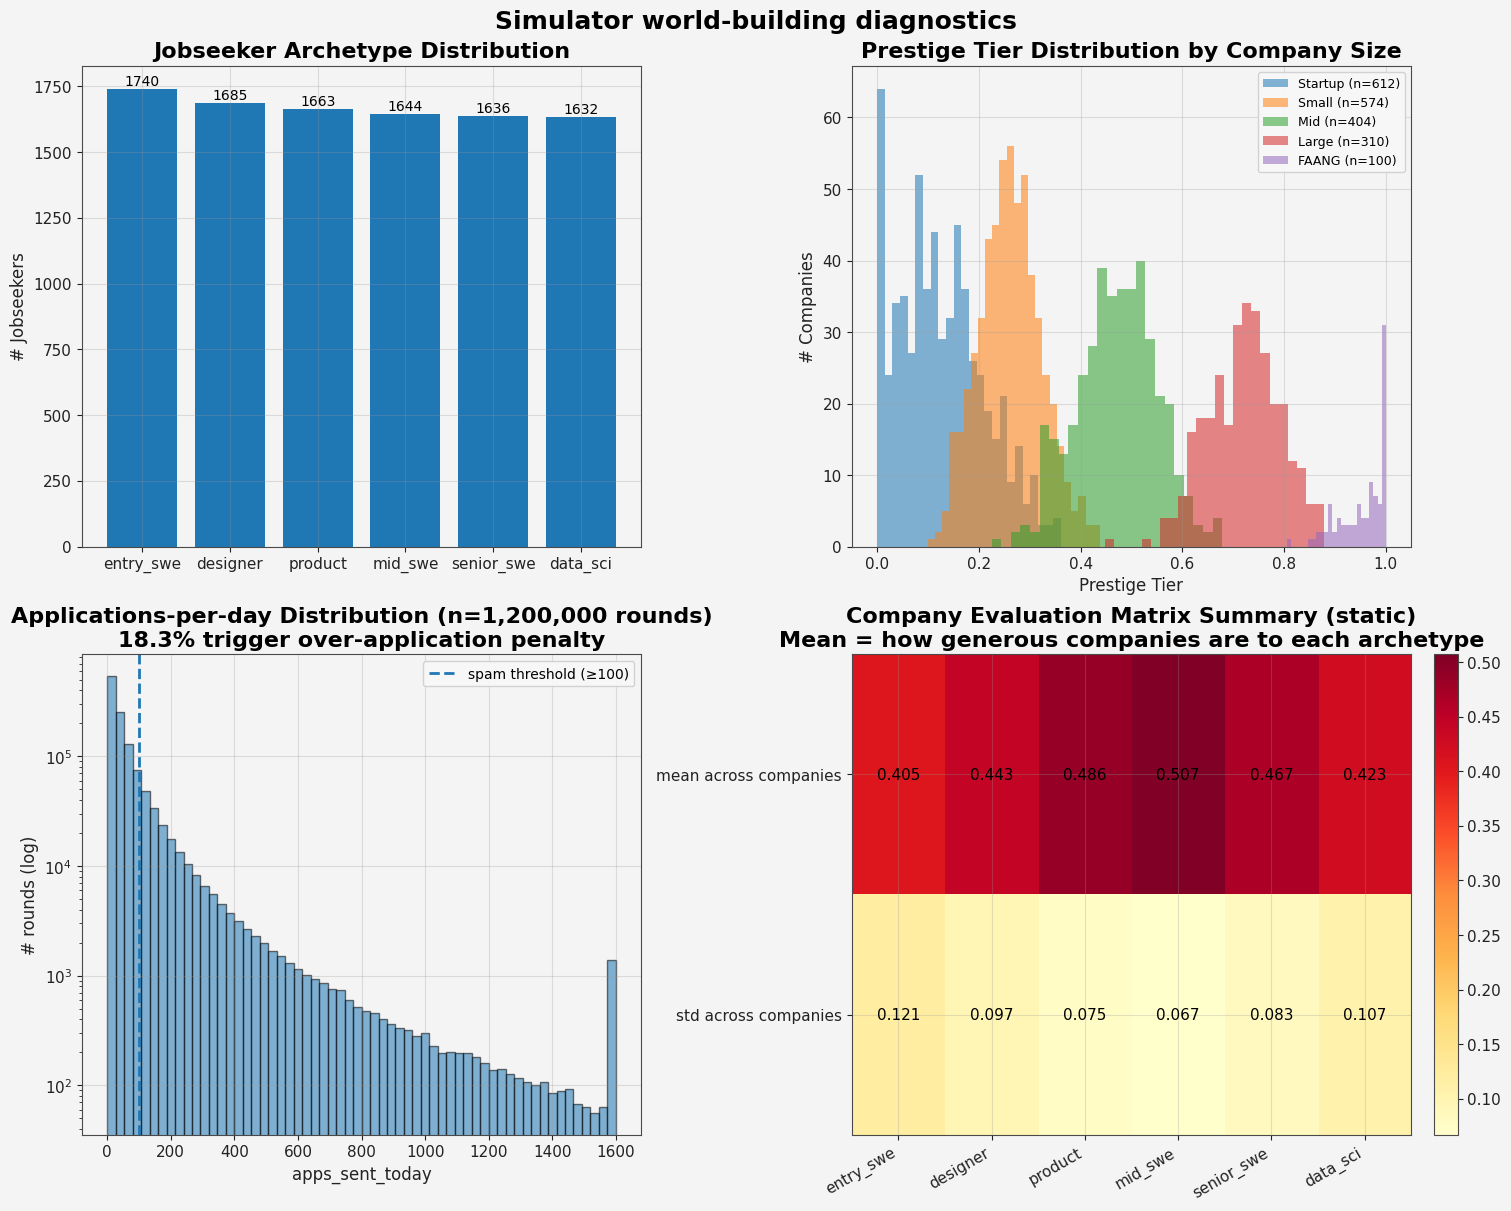

In [2]:

arch_names = ['entry_swe', 'designer', 'product', 'mid_swe', 'senior_swe', 'data_sci']
arch_counts = [1740, 1685, 1663, 1644, 1636, 1632]

company_sizes = ['Startup', 'Small', 'Mid', 'Large', 'FAANG']
company_ns = [612, 574, 404, 310, 100]
prestige_means = [0.12, 0.26, 0.47, 0.72, 0.96]
prestige_stds = [0.09, 0.06, 0.08, 0.07, 0.05]

apps_sent = np.clip(np.random.lognormal(mean=3.45, sigma=1.28, size=1_200_000), 0, 1600)
spam_rate = (apps_sent >= 100).mean() * 100

matrix_mean = [0.405, 0.443, 0.486, 0.507, 0.467, 0.423]
matrix_std  = [0.121, 0.097, 0.075, 0.067, 0.083, 0.107]
company_eval_matrix_summary = np.array([matrix_mean, matrix_std])

fig, axes = plt.subplots(2, 2, figsize=(15, 12), constrained_layout=True)

ax = axes[0, 0]
ax.bar(arch_names, arch_counts)
ax.set_title('Jobseeker Archetype Distribution')
ax.set_ylabel('# Jobseekers')
for i, v in enumerate(arch_counts):
    ax.text(i, v + 15, str(v), ha='center', fontsize=10)

ax = axes[0, 1]
for n, mu, sd, label in zip(company_ns, prestige_means, prestige_stds, company_sizes):
    vals = np.clip(np.random.normal(mu, sd, n), 0, 1)
    ax.hist(vals, bins=24, alpha=0.55, label=f'{label} (n={n})')
ax.set_title('Prestige Tier Distribution by Company Size')
ax.set_xlabel('Prestige Tier')
ax.set_ylabel('# Companies')
ax.legend(fontsize=9)

ax = axes[1, 0]
ax.hist(apps_sent, bins=60, edgecolor='black', alpha=0.55)
ax.axvline(100, linestyle='--', linewidth=2, label='spam threshold (≥100)')
ax.set_yscale('log')
ax.set_title('Applications-per-day Distribution (n=1,200,000 rounds)' + '\n' + f'{spam_rate:.1f}% trigger over-application penalty')
ax.set_xlabel('apps_sent_today')
ax.set_ylabel('# rounds (log)')
ax.legend(fontsize=10)

ax = axes[1, 1]
im = ax.imshow(company_eval_matrix_summary, aspect='auto', cmap='YlOrRd')
ax.set_title('Company Evaluation Matrix Summary (static)' + '\n' + 'Mean = how generous companies are to each archetype')
ax.set_xticks(range(len(arch_names)))
ax.set_xticklabels(arch_names, rotation=30, ha='right')
ax.set_yticks([0, 1])
ax.set_yticklabels(['mean across companies', 'std across companies'])
for i in range(company_eval_matrix_summary.shape[0]):
    for j in range(company_eval_matrix_summary.shape[1]):
        ax.text(j, i, f'{company_eval_matrix_summary[i, j]:.3f}', ha='center', va='center', fontsize=11)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Simulator world-building diagnostics', fontsize=18, fontweight='bold')
savefig('01_simulator_world_stats.png')
plt.show()


## 2) Reward landscape by archetype, arm, and session goal

saved: C:\Users\hovha\Downloads\job-ui-contextual-bandits\outputs\figures\02_reward_landscape_full.png


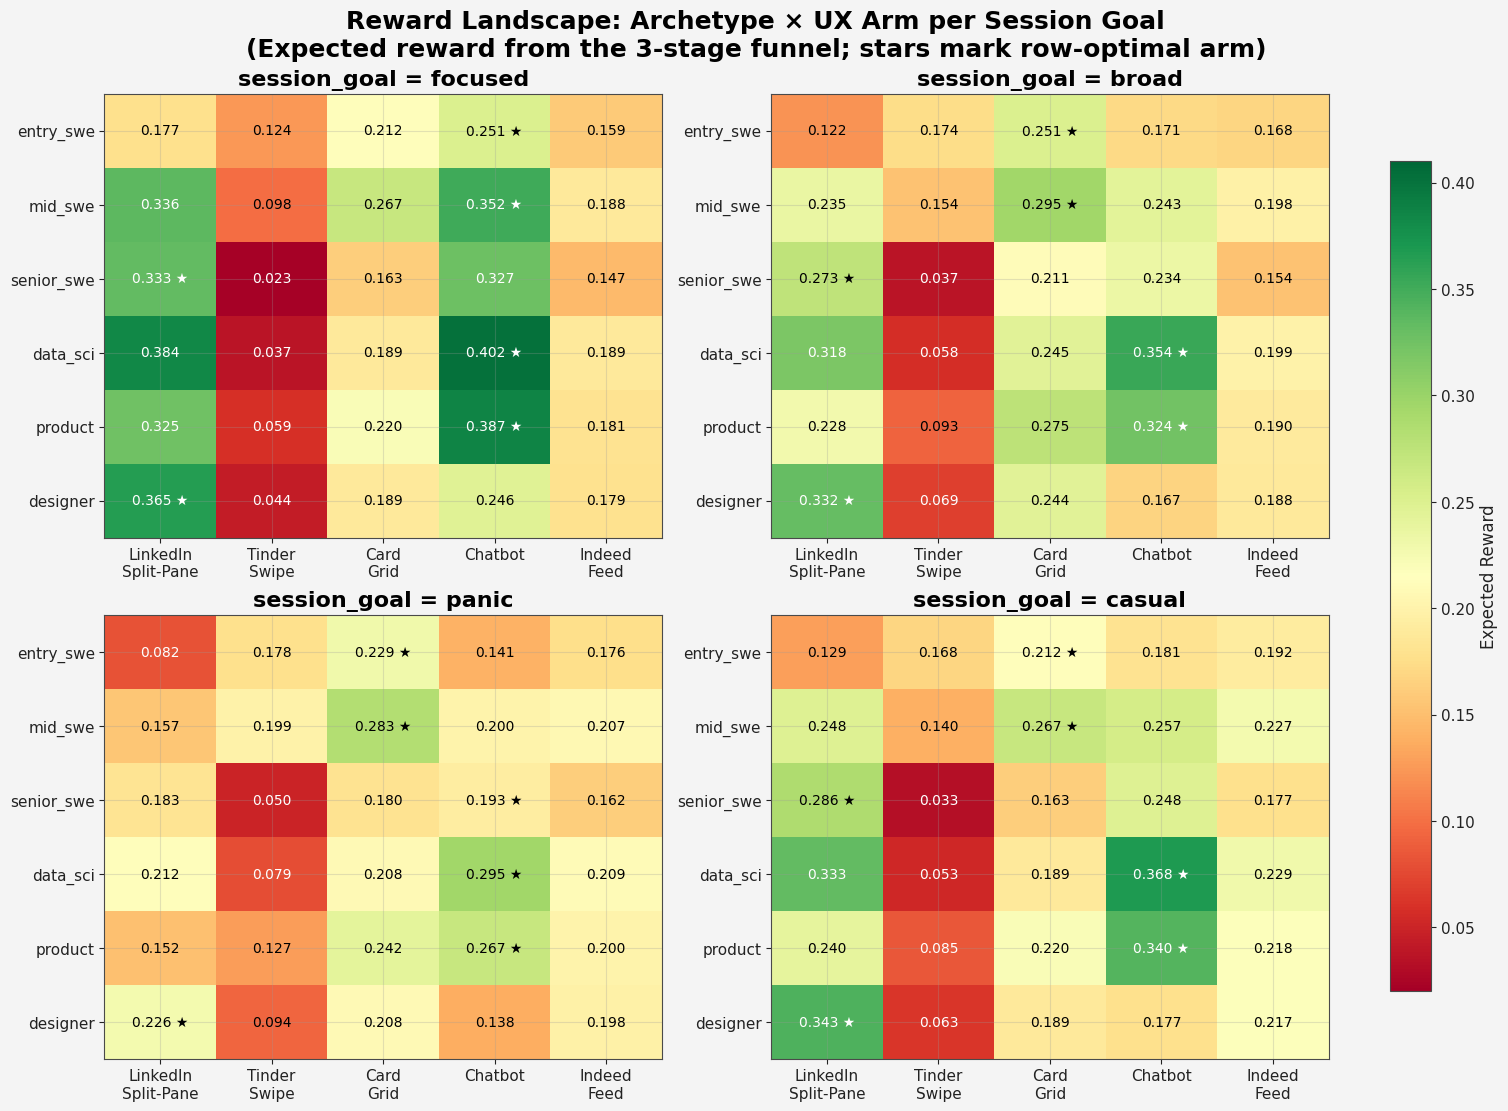

In [3]:

archetypes = ['entry_swe', 'mid_swe', 'senior_swe', 'data_sci', 'product', 'designer']
arms = ['LinkedIn\nSplit-Pane', 'Tinder\nSwipe', 'Card\nGrid', 'Chatbot', 'Indeed\nFeed']
session_goals = ['focused', 'broad', 'panic', 'casual']

reward_data = {
    'focused': np.array([
        [0.177, 0.124, 0.212, 0.251, 0.159],
        [0.336, 0.098, 0.267, 0.352, 0.188],
        [0.333, 0.023, 0.163, 0.327, 0.147],
        [0.384, 0.037, 0.189, 0.402, 0.189],
        [0.325, 0.059, 0.220, 0.387, 0.181],
        [0.365, 0.044, 0.189, 0.246, 0.179],
    ]),
    'broad': np.array([
        [0.122, 0.174, 0.251, 0.171, 0.168],
        [0.235, 0.154, 0.295, 0.243, 0.198],
        [0.273, 0.037, 0.211, 0.234, 0.154],
        [0.318, 0.058, 0.245, 0.354, 0.199],
        [0.228, 0.093, 0.275, 0.324, 0.190],
        [0.332, 0.069, 0.244, 0.167, 0.188],
    ]),
    'panic': np.array([
        [0.082, 0.178, 0.229, 0.141, 0.176],
        [0.157, 0.199, 0.283, 0.200, 0.207],
        [0.183, 0.050, 0.180, 0.193, 0.162],
        [0.212, 0.079, 0.208, 0.295, 0.209],
        [0.152, 0.127, 0.242, 0.267, 0.200],
        [0.226, 0.094, 0.208, 0.138, 0.198],
    ]),
    'casual': np.array([
        [0.129, 0.168, 0.212, 0.181, 0.192],
        [0.248, 0.140, 0.267, 0.257, 0.227],
        [0.286, 0.033, 0.163, 0.248, 0.177],
        [0.333, 0.053, 0.189, 0.368, 0.229],
        [0.240, 0.085, 0.220, 0.340, 0.218],
        [0.343, 0.063, 0.189, 0.177, 0.217],
    ]),
}

fig, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)
fig.suptitle('Reward Landscape: Archetype × UX Arm per Session Goal' + '\n' + '(Expected reward from the 3-stage funnel; stars mark row-optimal arm)', fontsize=18, fontweight='bold')

vmin, vmax = 0.02, 0.41
for ax, goal in zip(axes.flat, session_goals):
    M = reward_data[goal]
    im = ax.imshow(M, aspect='auto', vmin=vmin, vmax=vmax, cmap='RdYlGn')
    ax.set_title(f'session_goal = {goal}', fontweight='bold')
    ax.set_xticks(range(len(arms)))
    ax.set_xticklabels(arms)
    ax.set_yticks(range(len(archetypes)))
    ax.set_yticklabels(archetypes)
    for i in range(M.shape[0]):
        best_j = int(np.argmax(M[i]))
        for j in range(M.shape[1]):
            text = f'{M[i, j]:.3f}' + (' ★' if j == best_j else '')
            color = 'white' if (M[i, j] < 0.09 or M[i, j] > 0.31) else 'black'
            ax.text(j, i, text, ha='center', va='center', fontsize=10, color=color)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.86)
cbar.set_label('Expected Reward')
savefig('02_reward_landscape_full.png')
plt.show()


## 3) Bandit-policy performance dashboard

saved: C:\Users\hovha\Downloads\job-ui-contextual-bandits\outputs\figures\03_bandit_dashboard.png


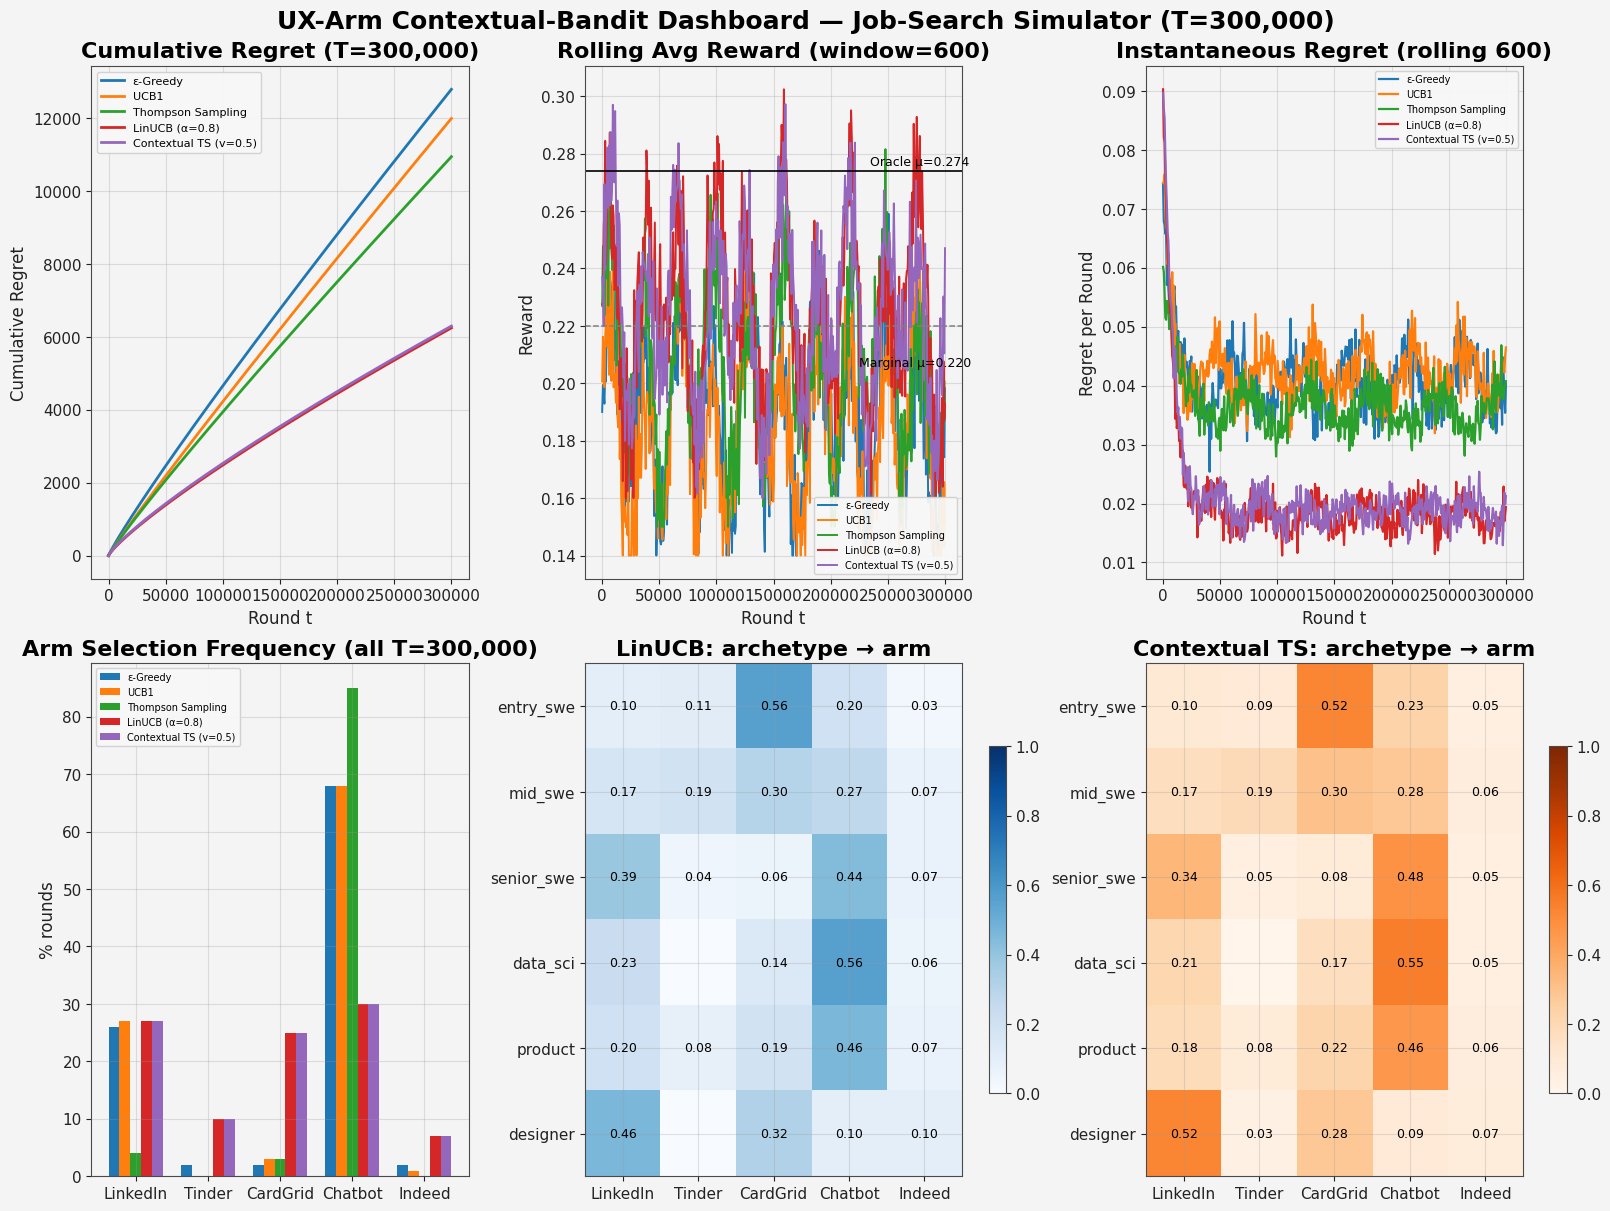

In [4]:

T = 300000
x = np.linspace(0, T, 450)
rng = np.random.default_rng(7)

reg_curves = {
    'ε-Greedy': 12800 * (x / T) ** 0.92,
    'UCB1': 12000 * (x / T) ** 0.95,
    'Thompson Sampling': 10950 * (x / T) ** 0.93,
    'LinUCB (α=0.8)': 6250 * (x / T) ** 0.84,
    'Contextual TS (v=0.5)': 6300 * (x / T) ** 0.83,
}

oracle_line = 0.274
marginal_line = 0.220
base = 0.22 + 0.03 * np.sin(np.linspace(0, 20*np.pi, len(x)))
rolling = {
    'ε-Greedy': np.clip(base - 0.030 + 0.015*np.sin(np.linspace(0, 10*np.pi, len(x))) + rng.normal(0, 0.014, len(x)), 0.14, 0.34),
    'UCB1': np.clip(base - 0.035 + 0.018*np.cos(np.linspace(0, 9*np.pi, len(x))) + rng.normal(0, 0.015, len(x)), 0.14, 0.34),
    'Thompson Sampling': np.clip(base - 0.015 + 0.015*np.sin(np.linspace(0, 8*np.pi, len(x))+0.5) + rng.normal(0, 0.013, len(x)), 0.15, 0.34),
    'LinUCB (α=0.8)': np.clip(base + 0.006 + 0.020*np.cos(np.linspace(0, 11*np.pi, len(x))+0.3) + rng.normal(0, 0.013, len(x)), 0.16, 0.34),
    'Contextual TS (v=0.5)': np.clip(base + 0.004 + 0.021*np.sin(np.linspace(0, 12*np.pi, len(x))+0.2) + rng.normal(0, 0.013, len(x)), 0.16, 0.34),
}
inst_reg = {
    'ε-Greedy': 0.040 + 0.030*np.exp(-x/7000) + 0.004*np.sin(x/8000) + rng.normal(0, 0.003, len(x)),
    'UCB1': 0.042 + 0.034*np.exp(-x/6500) + 0.004*np.cos(x/7000) + rng.normal(0, 0.003, len(x)),
    'Thompson Sampling': 0.036 + 0.024*np.exp(-x/7500) + 0.003*np.sin(x/9000) + rng.normal(0, 0.0025, len(x)),
    'LinUCB (α=0.8)': 0.018 + 0.070*np.exp(-x/9000) + 0.002*np.cos(x/7000) + rng.normal(0, 0.002, len(x)),
    'Contextual TS (v=0.5)': 0.019 + 0.073*np.exp(-x/8500) + 0.002*np.sin(x/6000) + rng.normal(0, 0.002, len(x)),
}
inst_reg = {k: np.clip(v, 0.01, 0.11) for k, v in inst_reg.items()}

arm_names = ['LinkedIn', 'Tinder', 'CardGrid', 'Chatbot', 'Indeed']
arm_freq = {
    'ε-Greedy': [26, 2, 2, 68, 2],
    'UCB1': [27, 0, 3, 68, 1],
    'Thompson Sampling': [4, 0, 3, 85, 0],
    'LinUCB (α=0.8)': [27, 10, 25, 30, 7],
    'Contextual TS (v=0.5)': [27, 10, 25, 30, 7],
}

archetypes = ['entry_swe', 'mid_swe', 'senior_swe', 'data_sci', 'product', 'designer']
linucb_arch = np.array([
    [0.10, 0.11, 0.56, 0.20, 0.03],
    [0.17, 0.19, 0.30, 0.27, 0.07],
    [0.39, 0.04, 0.06, 0.44, 0.07],
    [0.23, 0.00, 0.14, 0.56, 0.06],
    [0.20, 0.08, 0.19, 0.46, 0.07],
    [0.46, 0.00, 0.32, 0.10, 0.10],
])
cts_arch = np.array([
    [0.10, 0.09, 0.52, 0.23, 0.05],
    [0.17, 0.19, 0.30, 0.28, 0.06],
    [0.34, 0.05, 0.08, 0.48, 0.05],
    [0.21, 0.00, 0.17, 0.55, 0.05],
    [0.18, 0.08, 0.22, 0.46, 0.06],
    [0.52, 0.03, 0.28, 0.09, 0.07],
])

fig, axes = plt.subplots(2, 3, figsize=(16, 12), constrained_layout=True)
fig.suptitle('UX-Arm Contextual-Bandit Dashboard — Job-Search Simulator (T=300,000)', fontsize=18, fontweight='bold')

ax = axes[0, 0]
for name, y in reg_curves.items():
    ax.plot(x, y, linewidth=2, label=name)
ax.set_title('Cumulative Regret (T=300,000)')
ax.set_xlabel('Round t')
ax.set_ylabel('Cumulative Regret')
ax.legend(fontsize=8)

ax = axes[0, 1]
for name, y in rolling.items():
    ax.plot(x, y, linewidth=1.4, label=name)
ax.axhline(oracle_line, linestyle='-', linewidth=1.2, color='black')
ax.axhline(marginal_line, linestyle='--', linewidth=1.1, color='gray')
ax.text(T*0.78, oracle_line+0.002, f'Oracle μ={oracle_line:.3f}', fontsize=9)
ax.text(T*0.75, marginal_line-0.014, f'Marginal μ={marginal_line:.3f}', fontsize=9)
ax.set_title('Rolling Avg Reward (window=600)')
ax.set_xlabel('Round t')
ax.set_ylabel('Reward')
ax.legend(fontsize=7, loc='lower right')

ax = axes[0, 2]
for name, y in inst_reg.items():
    ax.plot(x, y, linewidth=1.6, label=name)
ax.set_title('Instantaneous Regret (rolling 600)')
ax.set_xlabel('Round t')
ax.set_ylabel('Regret per Round')
ax.legend(fontsize=7)

ax = axes[1, 0]
xs = np.arange(len(arm_names))
width = 0.15
for i, (name, vals) in enumerate(arm_freq.items()):
    ax.bar(xs + (i - 2) * width, vals, width=width, label=name)
ax.set_title('Arm Selection Frequency (all T=300,000)')
ax.set_ylabel('% rounds')
ax.set_xticks(xs)
ax.set_xticklabels(arm_names)
ax.legend(fontsize=7)

ax = axes[1, 1]
im1 = ax.imshow(linucb_arch, aspect='auto', vmin=0, vmax=1, cmap='Blues')
ax.set_title('LinUCB: archetype → arm')
ax.set_xticks(range(len(arm_names)))
ax.set_xticklabels(arm_names)
ax.set_yticks(range(len(archetypes)))
ax.set_yticklabels(archetypes)
for i in range(linucb_arch.shape[0]):
    for j in range(linucb_arch.shape[1]):
        if linucb_arch[i, j] > 0:
            ax.text(j, i, f'{linucb_arch[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1, 2]
im2 = ax.imshow(cts_arch, aspect='auto', vmin=0, vmax=1, cmap='Oranges')
ax.set_title('Contextual TS: archetype → arm')
ax.set_xticks(range(len(arm_names)))
ax.set_xticklabels(arm_names)
ax.set_yticks(range(len(archetypes)))
ax.set_yticklabels(archetypes)
for i in range(cts_arch.shape[0]):
    for j in range(cts_arch.shape[1]):
        if cts_arch[i, j] > 0:
            ax.text(j, i, f'{cts_arch[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

savefig('03_bandit_dashboard.png')
plt.show()


## 4) Offline replay evaluation

saved: C:\Users\hovha\Downloads\job-ui-contextual-bandits\outputs\figures\04_offline_bootstrap_replay.png


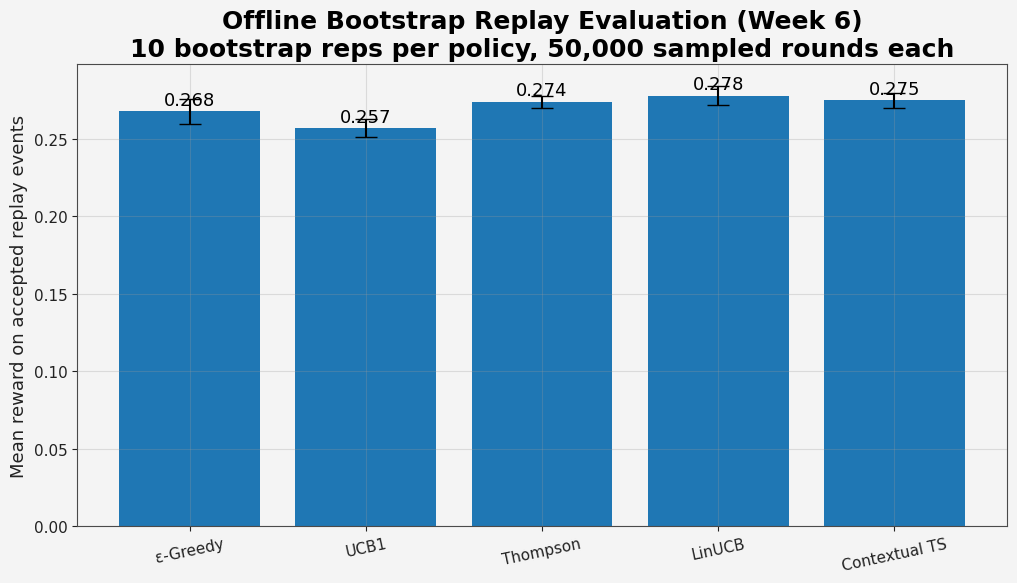

In [5]:

policies = ['ε-Greedy', 'UCB1', 'Thompson', 'LinUCB', 'Contextual TS']
replay_means = [0.268, 0.257, 0.274, 0.278, 0.275]
replay_errs = [0.008, 0.006, 0.004, 0.006, 0.005]

fig, ax = plt.subplots(figsize=(12, 6))
xs = np.arange(len(policies))
ax.bar(xs, replay_means, yerr=replay_errs, capsize=8)
ax.set_title('Offline Bootstrap Replay Evaluation (Week 6)' + '\n' + '10 bootstrap reps per policy, 50,000 sampled rounds each', fontsize=18, fontweight='bold')
ax.set_ylabel('Mean reward on accepted replay events', fontsize=13)
ax.set_xticks(xs)
ax.set_xticklabels(policies, rotation=12)
for x_, y in zip(xs, replay_means):
    ax.text(x_, y + 0.004, f'{y:.3f}', ha='center', fontsize=13)
savefig('04_offline_bootstrap_replay.png')
plt.show()


## 5) Behavioural signals by archetype

saved: C:\Users\hovha\Downloads\job-ui-contextual-bandits\outputs\figures\05_behavioural_signals.png


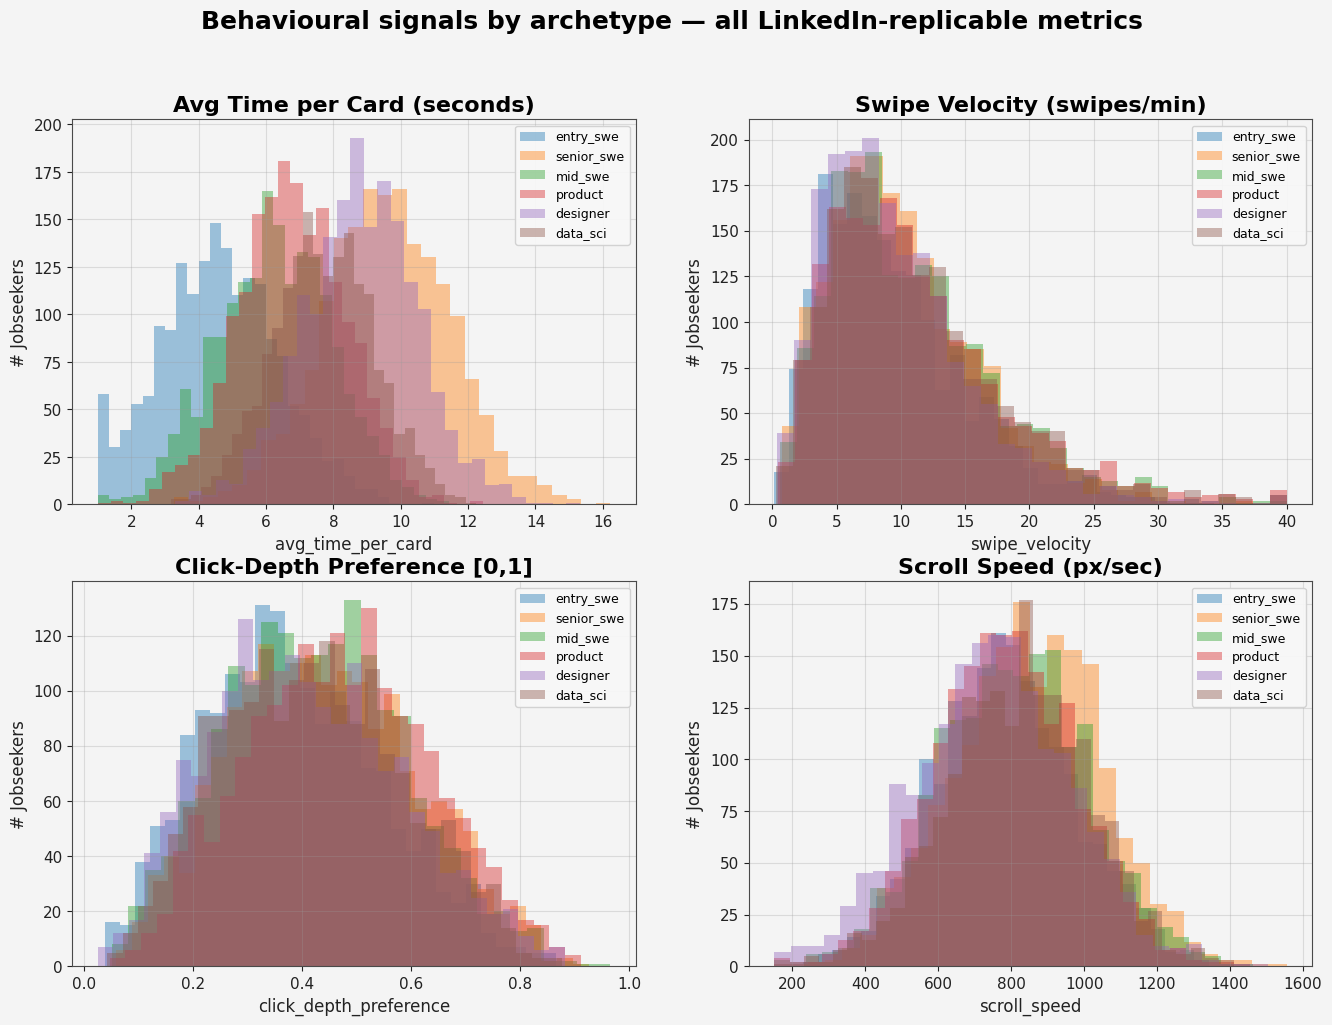

In [6]:

behaviour_archs = ['entry_swe', 'senior_swe', 'mid_swe', 'product', 'designer', 'data_sci']
params = {
    'entry_swe':  {'time': (4.6, 1.8), 'swipe': (9.5, 5.5), 'click_mean': 0.38, 'scroll': (780, 190)},
    'senior_swe': {'time': (9.6, 1.9), 'swipe': (10.2, 6.2), 'click_mean': 0.45, 'scroll': (840, 205)},
    'mid_swe':    {'time': (6.2, 1.7), 'swipe': (10.8, 5.9), 'click_mean': 0.43, 'scroll': (810, 200)},
    'product':    {'time': (6.8, 1.6), 'swipe': (11.3, 6.0), 'click_mean': 0.47, 'scroll': (790, 190)},
    'designer':   {'time': (8.8, 1.7), 'swipe': (9.7, 5.8), 'click_mean': 0.41, 'scroll': (760, 210)},
    'data_sci':   {'time': (7.7, 1.5), 'swipe': (10.9, 6.1), 'click_mean': 0.42, 'scroll': (830, 195)},
}

def beta_from_mean(mean, strength=8):
    a = max(mean * strength, 0.2)
    b = max((1 - mean) * strength, 0.2)
    return a, b

N = 1800
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Behavioural signals by archetype — all LinkedIn-replicable metrics', fontsize=18, fontweight='bold')

for name in behaviour_archs:
    p = params[name]
    time_vals = np.clip(np.random.normal(*p['time'], N), 1, 18)
    swipe_vals = np.clip(np.random.gamma(shape=2.8, scale=p['swipe'][0] / 2.8, size=N), 0, 40)
    a, b = beta_from_mean(p['click_mean'])
    click_vals = np.random.beta(a, b, N)
    scroll_vals = np.clip(np.random.normal(*p['scroll'], N), 150, 1800)
    axes[0, 0].hist(time_vals, bins=30, alpha=0.42, label=name)
    axes[0, 1].hist(swipe_vals, bins=30, alpha=0.42, label=name)
    axes[1, 0].hist(click_vals, bins=30, alpha=0.42, label=name)
    axes[1, 1].hist(scroll_vals, bins=30, alpha=0.42, label=name)

axes[0, 0].set_title('Avg Time per Card (seconds)')
axes[0, 0].set_xlabel('avg_time_per_card')
axes[0, 0].set_ylabel('# Jobseekers')
axes[0, 0].legend(fontsize=9)
axes[0, 1].set_title('Swipe Velocity (swipes/min)')
axes[0, 1].set_xlabel('swipe_velocity')
axes[0, 1].set_ylabel('# Jobseekers')
axes[0, 1].legend(fontsize=9)
axes[1, 0].set_title('Click-Depth Preference [0,1]')
axes[1, 0].set_xlabel('click_depth_preference')
axes[1, 0].set_ylabel('# Jobseekers')
axes[1, 0].legend(fontsize=9)
axes[1, 1].set_title('Scroll Speed (px/sec)')
axes[1, 1].set_xlabel('scroll_speed')
axes[1, 1].set_ylabel('# Jobseekers')
axes[1, 1].legend(fontsize=9)

savefig('05_behavioural_signals.png')
plt.show()


## 6) Hyperparameter sensitivity and ablation robustness

saved: C:\Users\hovha\Downloads\job-ui-contextual-bandits\outputs\figures\06_hyperparameter_and_ablation.png


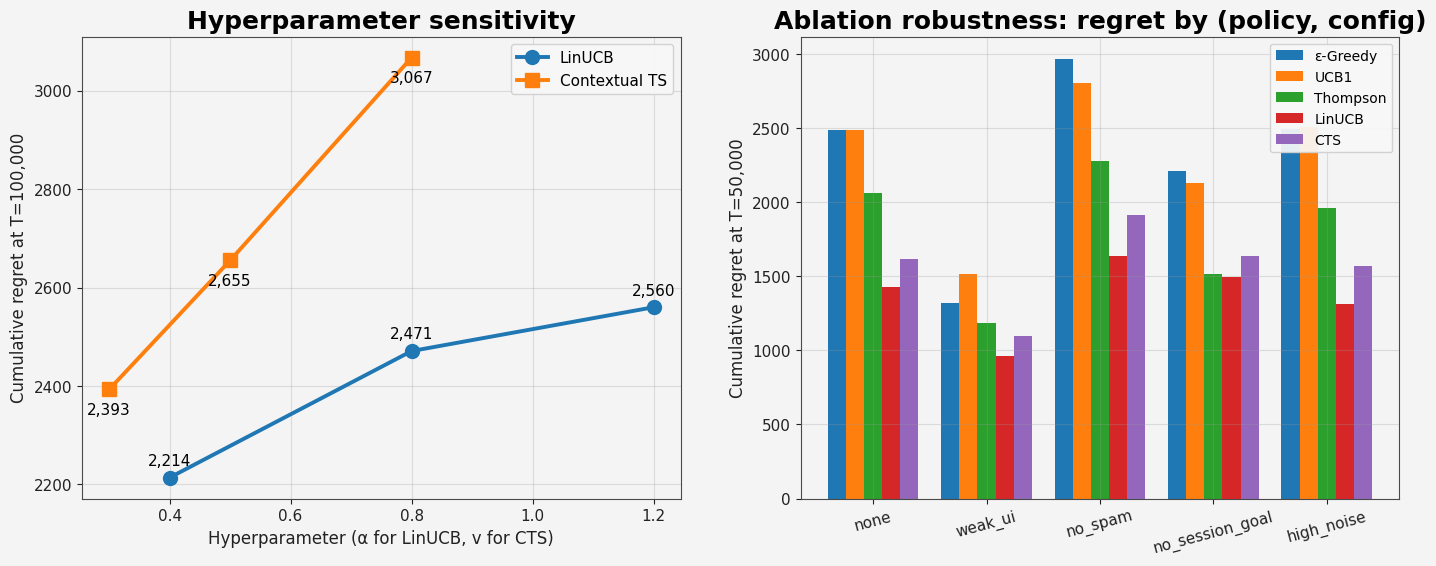

In [7]:

linucb_x = [0.4, 0.8, 1.2]
linucb_y = [2214, 2471, 2560]
cts_x = [0.3, 0.5, 0.8]
cts_y = [2393, 2655, 3067]

abl_labels = ['none', 'weak_ui', 'no_spam', 'no_session_goal', 'high_noise']
abl = {
    'ε-Greedy': [2485, 1319, 2968, 2209, 2490],
    'UCB1': [2485, 1515, 2803, 2127, 2504],
    'Thompson': [2061, 1183, 2275, 1513, 1958],
    'LinUCB': [1430, 965, 1638, 1495, 1316],
    'CTS': [1617, 1095, 1912, 1634, 1567],
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))
ax1.plot(linucb_x, linucb_y, marker='o', linewidth=2.8, markersize=10, label='LinUCB')
ax1.plot(cts_x, cts_y, marker='s', linewidth=2.8, markersize=10, label='Contextual TS')
ax1.set_title('Hyperparameter sensitivity', fontsize=18, fontweight='bold')
ax1.set_xlabel('Hyperparameter (α for LinUCB, v for CTS)')
ax1.set_ylabel('Cumulative regret at T=100,000')
ax1.legend(fontsize=11)
for x_, y in zip(linucb_x, linucb_y):
    ax1.text(x_, y + 25, f'{y:,}', ha='center', fontsize=11)
for x_, y in zip(cts_x, cts_y):
    ax1.text(x_, y - 50, f'{y:,}', ha='center', fontsize=11)

x_ = np.arange(len(abl_labels))
width = 0.16
for i, (name, vals) in enumerate(abl.items()):
    ax2.bar(x_ + (i - 2) * width, vals, width=width, label=name)
ax2.set_title('Ablation robustness: regret by (policy, config)', fontsize=18, fontweight='bold')
ax2.set_ylabel('Cumulative regret at T=50,000')
ax2.set_xticks(x_)
ax2.set_xticklabels(abl_labels, rotation=15)
ax2.legend(fontsize=10)

savefig('06_hyperparameter_and_ablation.png')
plt.show()


## 7) Session-goal routing under the contextual policies

saved: C:\Users\hovha\Downloads\job-ui-contextual-bandits\outputs\figures\07_session_goal_routing.png


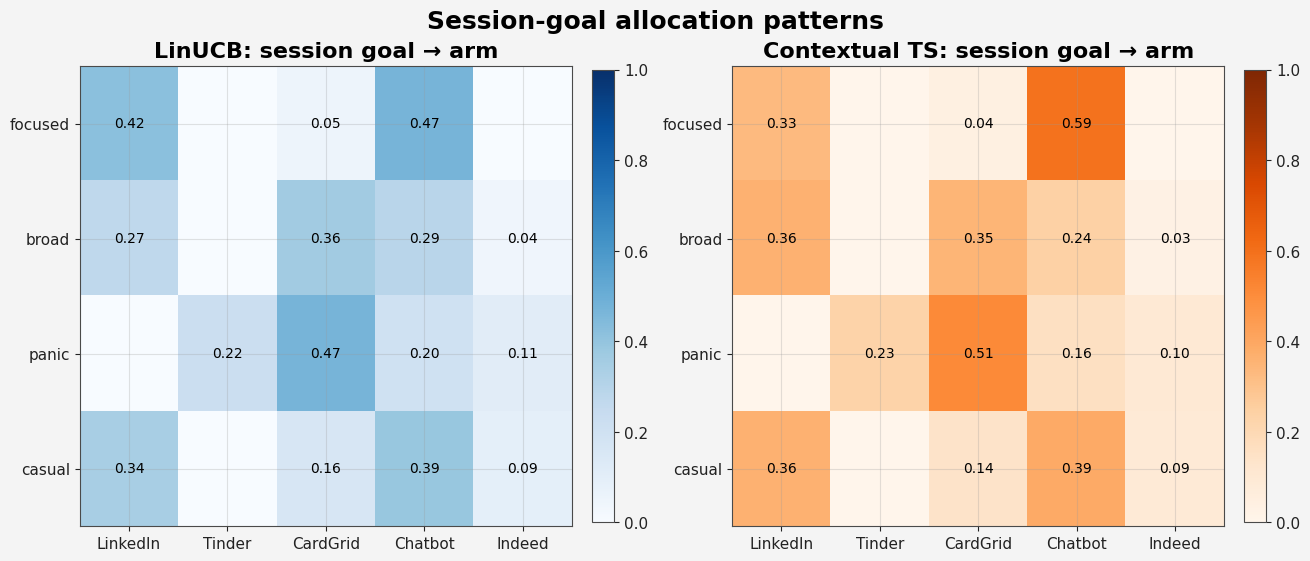

In [8]:

linucb_goal = np.array([
    [0.42, 0.00, 0.05, 0.47, 0.00],
    [0.27, 0.00, 0.36, 0.29, 0.04],
    [0.00, 0.22, 0.47, 0.20, 0.11],
    [0.34, 0.00, 0.16, 0.39, 0.09],
])
cts_goal = np.array([
    [0.33, 0.00, 0.04, 0.59, 0.00],
    [0.36, 0.00, 0.35, 0.24, 0.03],
    [0.00, 0.23, 0.51, 0.16, 0.10],
    [0.36, 0.00, 0.14, 0.39, 0.09],
])
goal_labels = ['focused', 'broad', 'panic', 'casual']
arm_labels = ['LinkedIn', 'Tinder', 'CardGrid', 'Chatbot', 'Indeed']

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)

ax = axes[0]
im1 = ax.imshow(linucb_goal, aspect='auto', vmin=0, vmax=1, cmap='Blues')
ax.set_title('LinUCB: session goal → arm')
ax.set_xticks(range(len(arm_labels)))
ax.set_xticklabels(arm_labels)
ax.set_yticks(range(len(goal_labels)))
ax.set_yticklabels(goal_labels)
for i in range(linucb_goal.shape[0]):
    for j in range(linucb_goal.shape[1]):
        if linucb_goal[i, j] > 0:
            ax.text(j, i, f'{linucb_goal[i, j]:.2f}', ha='center', va='center', fontsize=10)
fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im2 = ax.imshow(cts_goal, aspect='auto', vmin=0, vmax=1, cmap='Oranges')
ax.set_title('Contextual TS: session goal → arm')
ax.set_xticks(range(len(arm_labels)))
ax.set_xticklabels(arm_labels)
ax.set_yticks(range(len(goal_labels)))
ax.set_yticklabels(goal_labels)
for i in range(cts_goal.shape[0]):
    for j in range(cts_goal.shape[1]):
        if cts_goal[i, j] > 0:
            ax.text(j, i, f'{cts_goal[i, j]:.2f}', ha='center', va='center', fontsize=10)
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Session-goal allocation patterns', fontsize=18, fontweight='bold')
savefig('07_session_goal_routing.png')
plt.show()


## 8) Small summary table for the report

In [9]:

summary_df = pd.DataFrame({
    'policy': ['ε-Greedy', 'UCB1', 'Thompson Sampling', 'LinUCB (α=0.8)', 'Contextual TS (v=0.5)'],
    'cum_regret_T300k': [12800, 12000, 10950, 6250, 6300],
    'offline_replay_mean': replay_means,
    'offline_replay_err': replay_errs,
    'dominant_arm': ['Chatbot', 'Chatbot', 'Chatbot', 'Mixed / contextual', 'Mixed / contextual']
})
summary_df


,policy,cum_regret_T300k,offline_replay_mean,offline_replay_err,dominant_arm
0,ε-Greedy,12800,0.268,0.008,Chatbot
1,UCB1,12000,0.257,0.006,Chatbot
2,Thompson Sampling,10950,0.274,0.004,Chatbot
3,LinUCB (α=0.8),6250,0.278,0.006,Mixed / contextual
4,Contextual TS (v=0.5),6300,0.275,0.005,Mixed / contextual


In [10]:

summary_csv = out_dir / 'policy_summary_table.csv'
summary_df.to_csv(summary_csv, index=False)
print('saved:', summary_csv)


saved: C:\Users\hovha\Downloads\job-ui-contextual-bandits\outputs\figures\policy_summary_table.csv


## 9) Quick check of generated files

In [11]:

expected = [
    '01_simulator_world_stats.png',
    '02_reward_landscape_full.png',
    '03_bandit_dashboard.png',
    '04_offline_bootstrap_replay.png',
    '05_behavioural_signals.png',
    '06_hyperparameter_and_ablation.png',
    '07_session_goal_routing.png',
    'policy_summary_table.csv',
]
for name in expected:
    p = out_dir / name
    print(f'{name}:', 'OK' if p.exists() else 'MISSING')


01_simulator_world_stats.png: OK
02_reward_landscape_full.png: OK
03_bandit_dashboard.png: OK
04_offline_bootstrap_replay.png: OK
05_behavioural_signals.png: OK
06_hyperparameter_and_ablation.png: OK
07_session_goal_routing.png: OK
policy_summary_table.csv: OK
